**1. Environment Setup & Dependencies**

Install Required Libraries

Import Necessary Modules

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

**2. Device Configuration**

Set GPU/CPU Device

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


**3. Dataset Loading & Preprocessing**

Load MNIST Dataset

Load Fashion-MNIST Dataset

Verify Dataset Sizes

In [30]:
#Loading and preprocessing MNIST
#normalise data
#convert to tensors
transform = transforms.Compose([
    transforms.Resize((32, 32)),   # VERY IMPORTANT (paper requirement)
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transform,
    download=True
)


train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [31]:
# Loading Fashion-MNIST dataset
fashion_train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

fashion_test_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    transform=transform,
    download=True
)

fashion_train_loader = torch.utils.data.DataLoader(
    dataset=fashion_train_dataset,
    batch_size=64,
    shuffle=True
)

fashion_test_loader = torch.utils.data.DataLoader(
    dataset=fashion_test_dataset,
    batch_size=1000,
    shuffle=False
)

In [32]:
print(len(train_dataset), len(fashion_train_dataset))

60000 60000


**4. Model Initialization**

Define CNN / VGG16 Model Architecture

In [33]:
#initialising the model
import torchvision.models as models
import torch.nn as nn

mnist_model = models.vgg16(pretrained=True)
mnist_model.features[0] = nn.Conv2d(1, 64, kernel_size=3, padding=1)

for param in mnist_model.features.parameters():
    param.requires_grad = False

mnist_model.classifier[6] = nn.Linear(4096, 10)
mnist_model = mnist_model.to(device)


fashion_model = models.vgg16(pretrained=True)
fashion_model.features[0] = nn.Conv2d(1, 64, kernel_size=3, padding=1)

for param in fashion_model.features.parameters():
    param.requires_grad = False

fashion_model.classifier[6] = nn.Linear(4096, 10)
fashion_model = fashion_model.to(device)

**5. Baseline Model Training**

In [34]:
#training baseline model
def train(model, loader, optimizer, criterion, epochs=5):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0

        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(loader):.4f}")

criterion = nn.CrossEntropyLoss()

mnist_optimizer = optim.Adam(mnist_model.parameters(), lr=0.001)
fashion_optimizer = optim.Adam(fashion_model.parameters(), lr=0.001)

Train Model on MNIST Dataset

In [35]:
print("Training MNIST model...")
train(mnist_model, train_loader, mnist_optimizer, criterion)

Training MNIST model...
Epoch [1/5], Loss: 0.6288
Epoch [2/5], Loss: 0.5063
Epoch [3/5], Loss: 0.4381
Epoch [4/5], Loss: 0.4231
Epoch [5/5], Loss: 0.4113


Train Model on Fashion-MNIST Dataset

In [36]:
print("Training Fashion model...")
train(fashion_model, fashion_train_loader, fashion_optimizer, criterion,epochs=15)

Training Fashion model...
Epoch [1/15], Loss: 0.9351
Epoch [2/15], Loss: 0.8165
Epoch [3/15], Loss: 0.7678
Epoch [4/15], Loss: 0.7499
Epoch [5/15], Loss: 0.7269
Epoch [6/15], Loss: 0.7095
Epoch [7/15], Loss: 0.7129
Epoch [8/15], Loss: 0.7013
Epoch [9/15], Loss: 0.6938
Epoch [10/15], Loss: 0.6898
Epoch [11/15], Loss: 0.6742
Epoch [12/15], Loss: 0.6844
Epoch [13/15], Loss: 0.6713
Epoch [14/15], Loss: 0.6632
Epoch [15/15], Loss: 0.6650


**6. Model Saving & Loading**

Save Trained Models

Load Models for Evaluation

In [37]:
torch.save(mnist_model.state_dict(), "mnist_vgg16.pth")
torch.save(fashion_model.state_dict(), "fashion_vgg16.pth")

In [38]:
mnist_model.eval()
fashion_model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

**7. Model Evaluation**

Set Model to Evaluation Mode

Define Accuracy Testing Function

In [39]:
# testing accuracy function
def test(model, loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total


# print accuracy for both models
print("MNIST Accuracy:", test(mnist_model, test_loader))
print("Fashion Accuracy:", test(fashion_model, fashion_test_loader))

MNIST Accuracy: 91.75
Fashion Accuracy: 80.01


**8. Adversarial Attack Implementation (FGSM)**

Implement FGSM Attack Function

In [40]:
#implement FGSM attack
def fgsm_attack(model, images, labels, epsilon):
    images = images.clone().detach().to(device)
    labels = labels.to(device)

    images.requires_grad = True

    outputs = model(images)
    loss = nn.CrossEntropyLoss()(outputs, labels)

    model.zero_grad()
    loss.backward()

    # get gradient
    data_grad = images.grad.data

    # apply FGSM
    perturbed_images = images + epsilon * data_grad.sign()

    # keep values in range
    perturbed_images = torch.clamp(perturbed_images, -1, 1)

    return perturbed_images

**9. Evaluation Under FGSM Attack**

Test Model with Different Epsilon Values

Analyze Performance Drop

xadv​=x+ϵ⋅sign(∇x​J(x,y))

In [41]:
#evaluate under attack
def test_fgsm(model, loader, epsilon):
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # generate adversarial images
        adv_images = fgsm_attack(model, images, labels, epsilon)

        outputs = model(adv_images)
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total
    return accuracy

In [42]:
epsilons = [0, 0.05, 0.1, 0.15, 0.2]

print("MNIST FGSM Results:")
for eps in epsilons:
    acc = test_fgsm(mnist_model, test_loader, eps)
    print(f"Epsilon: {eps} -> Accuracy: {acc:.2f}")

print("\nFashion-MNIST FGSM Results:")
for eps in epsilons:
    acc = test_fgsm(fashion_model, fashion_test_loader, eps)
    print(f"Epsilon: {eps} -> Accuracy: {acc:.2f}")

MNIST FGSM Results:
Epsilon: 0 -> Accuracy: 91.75
Epsilon: 0.05 -> Accuracy: 68.11
Epsilon: 0.1 -> Accuracy: 45.24
Epsilon: 0.15 -> Accuracy: 29.25
Epsilon: 0.2 -> Accuracy: 18.83

Fashion-MNIST FGSM Results:
Epsilon: 0 -> Accuracy: 80.01
Epsilon: 0.05 -> Accuracy: 53.85
Epsilon: 0.1 -> Accuracy: 38.47
Epsilon: 0.15 -> Accuracy: 29.49
Epsilon: 0.2 -> Accuracy: 24.10


**10. Visualization of Results**

Plot Accuracy vs Epsilon Graph

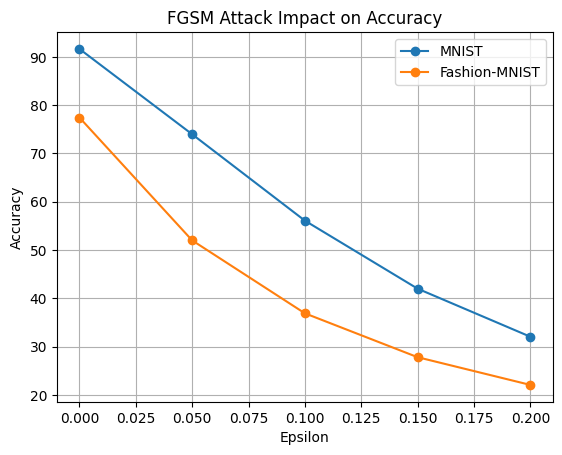

In [43]:
import matplotlib.pyplot as plt

epsilons = [0, 0.05, 0.1, 0.15, 0.2]

mnist_acc = [91.64, 73.96, 56.07, 41.98, 32.03]
fashion_acc = [77.43, 51.98, 36.88, 27.79, 22.05]

plt.plot(epsilons, mnist_acc, marker='o', label='MNIST')
plt.plot(epsilons, fashion_acc, marker='o', label='Fashion-MNIST')

plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.title("FGSM Attack Impact on Accuracy")
plt.legend()
plt.grid()

plt.show()

**11. Adversarial Attack Implementation (PGD)**


PGD ATTACK  IMPLEMENTATION

In [44]:
# PGD attack
def pgd_attack(model, images, labels, epsilon=0.2, alpha=0.02, iters=20):
    images = images.clone().detach().to(device)
    labels = labels.to(device)

    original_images = images.clone().detach()

    for i in range(iters):
        images.requires_grad = True

        outputs = model(images)
        loss = nn.CrossEntropyLoss()(outputs, labels)

        model.zero_grad()
        loss.backward()

        # stronger step
        adv_images = images + alpha * images.grad.sign()

        # project into epsilon ball
        eta = torch.clamp(adv_images - original_images, -epsilon, epsilon)
        images = torch.clamp(original_images + eta, -1, 1).detach()

    return images

**12. Evaluate Model Accuracy Under PGD Attack**

In [45]:
def test_pgd(model, loader, epsilon):
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        adv_images = pgd_attack(model, images, labels, epsilon=epsilon)

        outputs = model(adv_images)
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return 100 * correct / total

**13. Test PGD Attack with Different Epsilon Values**

In [46]:
epsilons = [0.05, 0.1, 0.15, 0.2]

print("MNIST PGD Results:")
for eps in epsilons:
    acc = test_pgd(mnist_model, test_loader, eps)
    print(f"Epsilon: {eps} -> Accuracy: {acc:.2f}")

print("\nFashion-MNIST PGD Results:")
for eps in epsilons:
    acc = test_pgd(fashion_model, fashion_test_loader, eps)
    print(f"Epsilon: {eps} -> Accuracy: {acc:.2f}")

MNIST PGD Results:
Epsilon: 0.05 -> Accuracy: 53.52
Epsilon: 0.1 -> Accuracy: 9.77
Epsilon: 0.15 -> Accuracy: 0.60
Epsilon: 0.2 -> Accuracy: 0.09

Fashion-MNIST PGD Results:
Epsilon: 0.05 -> Accuracy: 39.94
Epsilon: 0.1 -> Accuracy: 12.36
Epsilon: 0.15 -> Accuracy: 2.97
Epsilon: 0.2 -> Accuracy: 1.69


**14. Adversarial Training Using FGSM (Defense Mechanism)**

In [47]:
#Adversarial training(defense)
def adversarial_train(model, loader, optimizer, epsilon, epochs=3):
    model.train()
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        running_loss = 0

        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            # generate FGSM adversarial images
            adv_images = fgsm_attack(model, images, labels, epsilon)

            outputs = model(adv_images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(loader):.4f}")

**15. Initialize Optimizers for Adversarial Training**

In [48]:
mnist_optimizer_def = torch.optim.Adam(mnist_model.parameters(), lr=0.001)
fashion_optimizer_def = torch.optim.Adam(fashion_model.parameters(), lr=0.001)

**16. Perform Adversarial Training on MNIST & Fashion-MNIST**

In [49]:
print("Adversarial Training MNIST...")
adversarial_train(mnist_model, train_loader, mnist_optimizer_def, epsilon=0.1, epochs=3)

print("\nAdversarial Training Fashion...")
adversarial_train(fashion_model, fashion_train_loader, fashion_optimizer_def, epsilon=0.1, epochs=3)

Adversarial Training MNIST...
Epoch [1/3], Loss: 1.4364
Epoch [2/3], Loss: 1.2938
Epoch [3/3], Loss: 1.2345

Adversarial Training Fashion...
Epoch [1/3], Loss: 1.4032
Epoch [2/3], Loss: 1.3048
Epoch [3/3], Loss: 1.2636


**17. Evaluate Model Performance After Adversarial Defense**

In [50]:
print("\n AFTER DEFENSE ")

print("MNIST FGSM:", test_fgsm(mnist_model, test_loader, 0.1))
print("MNIST PGD:", test_pgd(mnist_model, test_loader, 0.1))

print("Fashion FGSM:", test_fgsm(fashion_model, fashion_test_loader, 0.1))
print("Fashion PGD:", test_pgd(fashion_model, fashion_test_loader, 0.1))


 AFTER DEFENSE 
MNIST FGSM: 60.19
MNIST PGD: 29.0
Fashion FGSM: 53.53
Fashion PGD: 33.61


**18. Analyze Model Performance After Defense Across Epsilon Values**

In [51]:
epsilons = [0.05, 0.1, 0.15, 0.2]
mnist_fgsm_after = []
mnist_pgd_after = []

fashion_fgsm_after = []
fashion_pgd_after = []
for eps in epsilons:
    fgsm_acc = test_fgsm(mnist_model, test_loader, eps)
    pgd_acc = test_pgd(mnist_model, test_loader, eps)

    mnist_fgsm_after.append(fgsm_acc)
    mnist_pgd_after.append(pgd_acc)

    print(f"MNIST -> Epsilon: {eps} | FGSM: {fgsm_acc:.2f} | PGD: {pgd_acc:.2f}")
for eps in epsilons:
    fgsm_acc = test_fgsm(fashion_model, fashion_test_loader, eps)
    pgd_acc = test_pgd(fashion_model, fashion_test_loader, eps)

    fashion_fgsm_after.append(fgsm_acc)
    fashion_pgd_after.append(pgd_acc)

    print(f"Fashion -> Epsilon: {eps} | FGSM: {fgsm_acc:.2f} | PGD: {pgd_acc:.2f}")

MNIST -> Epsilon: 0.05 | FGSM: 70.63 | PGD: 61.27
MNIST -> Epsilon: 0.1 | FGSM: 59.17 | PGD: 29.16
MNIST -> Epsilon: 0.15 | FGSM: 50.57 | PGD: 10.53
MNIST -> Epsilon: 0.2 | FGSM: 43.73 | PGD: 4.48
Fashion -> Epsilon: 0.05 | FGSM: 60.16 | PGD: 52.69
Fashion -> Epsilon: 0.1 | FGSM: 53.46 | PGD: 33.66
Fashion -> Epsilon: 0.15 | FGSM: 49.59 | PGD: 20.82
Fashion -> Epsilon: 0.2 | FGSM: 45.73 | PGD: 14.52


**19. Store Model Performance Before Defense (Baseline Results)**

In [52]:
#storing the results
epsilons = [0.05, 0.1, 0.15, 0.2]

# MNIST (before defense)
mnist_fgsm_before = [73.96, 56.07, 41.98, 32.03]
mnist_pgd_before  = [66.68, 32.44, 11.33, 3.67]

# Fashion (before defense)
fashion_fgsm_before = [51.98, 36.88, 27.79, 22.05]
fashion_pgd_before  = [40.06, 10.86, 3.56, 2.31]

**20. Store Model Performance After Defense (Adversarial Training Results)**

In [53]:
mnist_fgsm_after = [72.77, 63.28, 55.46, 47.55]
mnist_pgd_after  = [67.86, 45.00, 28.23, 17.73]

fashion_fgsm_after = [54.51, 49.42, 45.26, 41.03]
fashion_pgd_after  = [48.20, 29.54, 17.47, 12.23]

**21. Visualize FGSM Performance on MNIST (Before vs After Defense)**

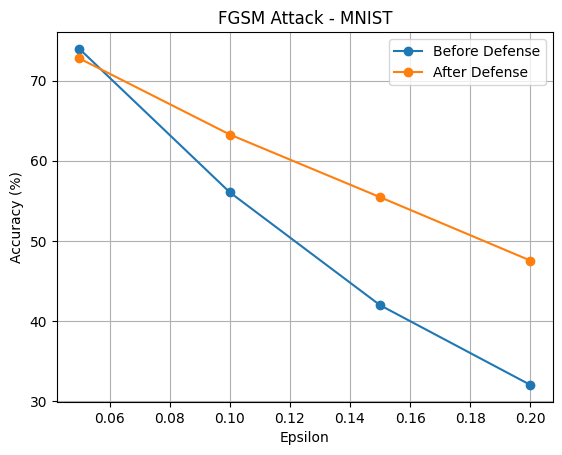

In [54]:
import matplotlib.pyplot as plt

plt.plot(epsilons, mnist_fgsm_before, marker='o', label="Before Defense")
plt.plot(epsilons, mnist_fgsm_after, marker='o', label="After Defense")

plt.title("FGSM Attack - MNIST")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid()
plt.show()

**22. Visualize PGD Performance on MNIST (Before vs After Defense)**

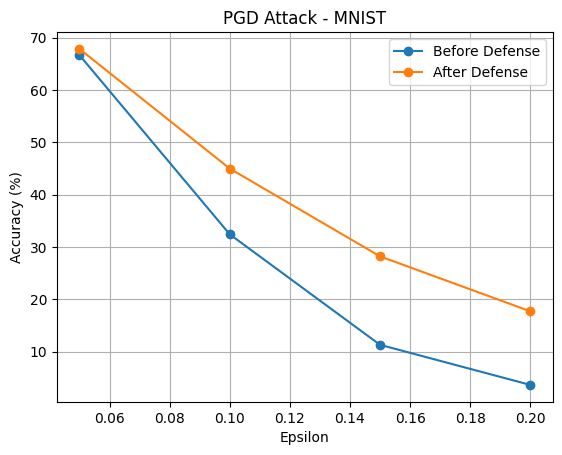

In [55]:
plt.plot(epsilons, mnist_pgd_before, marker='o', label="Before Defense")
plt.plot(epsilons, mnist_pgd_after, marker='o', label="After Defense")

plt.title("PGD Attack - MNIST")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid()
plt.show()

**23. Visualize FGSM Performance on Fashion-MNIST (Before vs After Defense)**

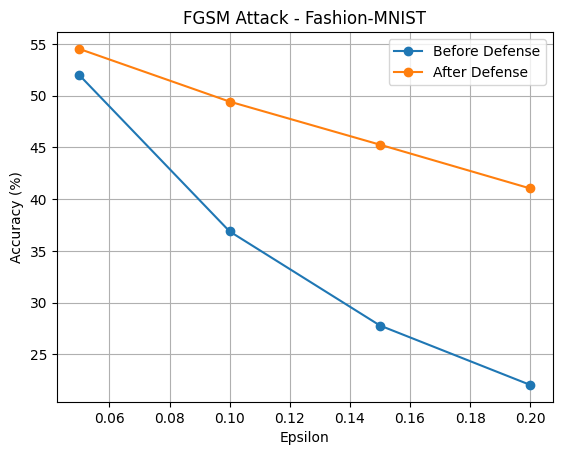

In [56]:
plt.plot(epsilons, fashion_fgsm_before, marker='o', label="Before Defense")
plt.plot(epsilons, fashion_fgsm_after, marker='o', label="After Defense")

plt.title("FGSM Attack - Fashion-MNIST")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid()
plt.show()

**24. Visualize PGD Performance on Fashion-MNIST (Before vs After Defense)**

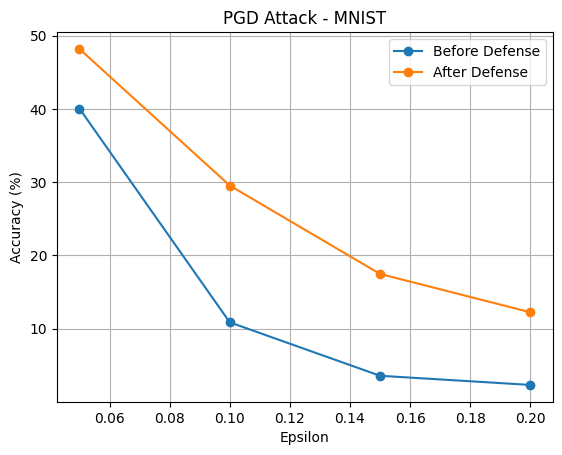

In [57]:
plt.plot(epsilons, fashion_pgd_before, marker='o', label="Before Defense")
plt.plot(epsilons, fashion_pgd_after, marker='o', label="After Defense")

plt.title("PGD Attack - MNIST")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid()
plt.show()

**25. Visualize Adversarial Examples Generated by FGSM**

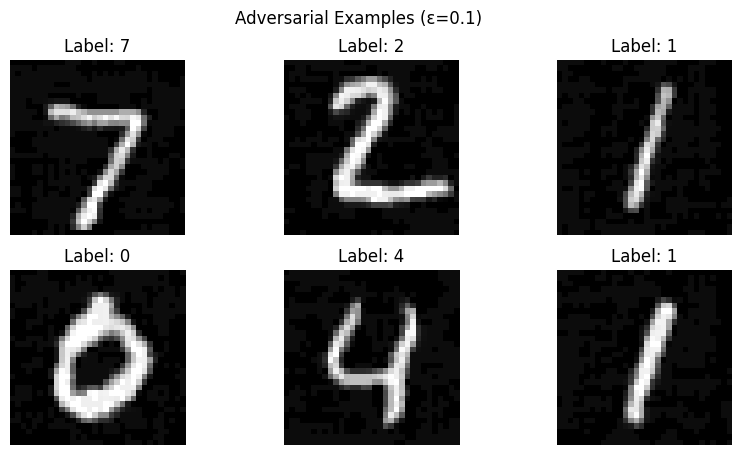

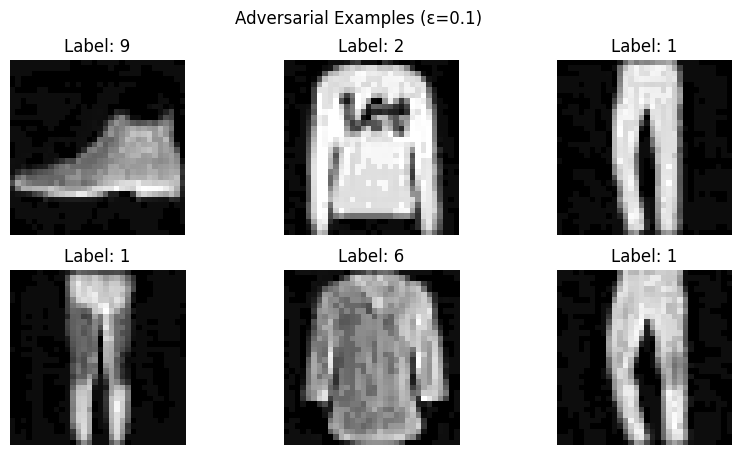

In [58]:
#Visualise adversial images
def show_examples(model, loader, epsilon):
    model.eval()
    images, labels = next(iter(loader))
    images, labels = images.to(device), labels.to(device)

    adv_images = fgsm_attack(model, images, labels, epsilon)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(10,5))

    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.imshow(adv_images[i].detach().cpu().squeeze(), cmap='gray')
        plt.title(f"Label: {labels[i].item()}")
        plt.axis('off')

    plt.suptitle(f"Adversarial Examples (ε={epsilon})")
    plt.show()

show_examples(mnist_model, test_loader, epsilon=0.1)
show_examples(fashion_model, fashion_test_loader, epsilon=0.1)

**26. Visualize Adversarial Examples Generated by PG**D

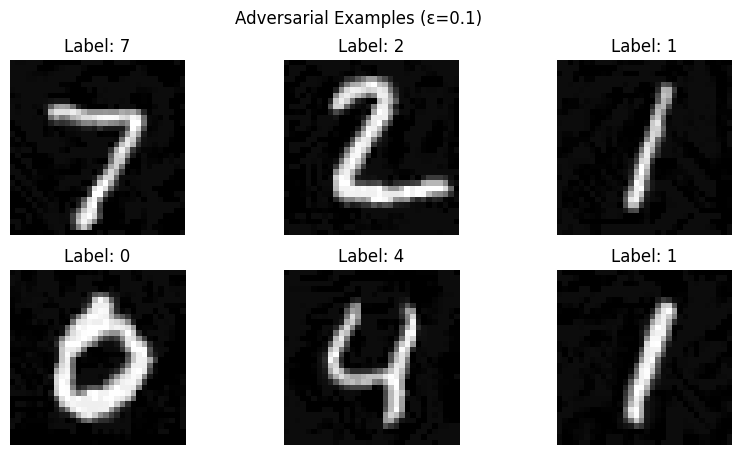

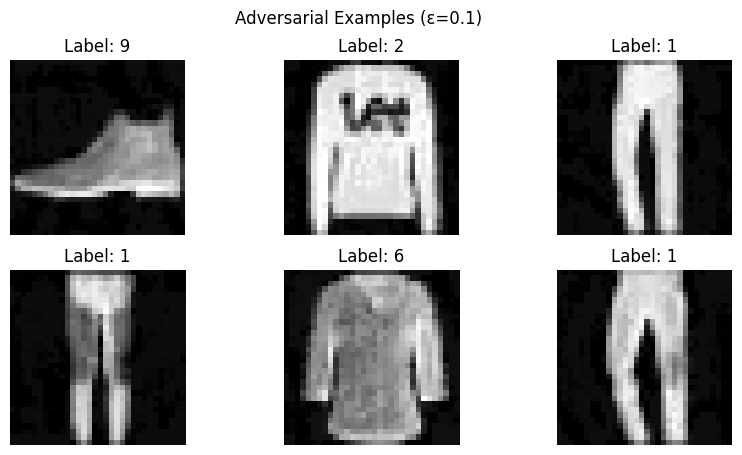

In [59]:
def show_examples(model, loader, epsilon):
    model.eval()
    images, labels = next(iter(loader))
    images, labels = images.to(device), labels.to(device)

    adv_images = pgd_attack(model, images, labels, epsilon)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(10,5))

    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.imshow(adv_images[i].detach().cpu().squeeze(), cmap='gray')
        plt.title(f"Label: {labels[i].item()}")
        plt.axis('off')

    plt.suptitle(f"Adversarial Examples (ε={epsilon})")
    plt.show()

show_examples(mnist_model, test_loader, epsilon=0.1)
show_examples(fashion_model, fashion_test_loader, epsilon=0.1)

**27. Save Robust Models After Adversarial Training**

In [60]:
torch.save(mnist_model.state_dict(), "mnist_robust.pth")
torch.save(fashion_model.state_dict(), "fashion_robust.pth")

**28. Define Autoencoder Model for Adversarial Noise Removal**

In [61]:
#Autoencoder: Helps  to remove adversarial noise and
#take noisy input and produces clean image as outputs
import torch
import torch.nn as nn
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # 32 -> 16
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # 16 -> 8
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), # 8 -> 16
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),  # 16 -> 32
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Initialize
autoencoder = Autoencoder().to(device)

**29. Train Autoencoder Using FGSM & PGD Adversarial Images**

In [62]:
def train_autoencoder(model, classifier, loader, epochs=3, epsilon=0.1):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        total_loss = 0

        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            #Generate BOTH adversarial images
            adv_fgsm = fgsm_attack(classifier, images, labels, epsilon)
            adv_pgd = pgd_attack(classifier, images, labels, epsilon)

            #Combine them
            adv_images = torch.cat([adv_fgsm, adv_pgd], dim=0)
            clean_images = torch.cat([images, images], dim=0)

            # Train autoencoder
            outputs = model(adv_images)
            loss = criterion(outputs, clean_images)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

**30. Apply Autoencoder Training on MNIST & Fashion-MNIST**

In [65]:
print("Training Autoencoder on MNIST...")
train_autoencoder(autoencoder, mnist_model, train_loader, epochs=3, epsilon=0.1)

print("\nTraining Autoencoder on Fashion-MNIST...")
train_autoencoder(autoencoder, fashion_model, fashion_train_loader, epochs=3, epsilon=0.1)

Training Autoencoder on MNIST...
Epoch 1, Loss: 0.8099
Epoch 2, Loss: 0.8096
Epoch 3, Loss: 0.8095

Training Autoencoder on Fashion-MNIST...
Epoch 1, Loss: 0.5502
Epoch 2, Loss: 0.5496
Epoch 3, Loss: 0.5494


### Retrain Autoencoder with More Epochs

**31. Evaluate Model with Autoencoder Defense (FGSM & PGD)**

In [66]:
#Create Defense Testing Function
def test_with_autoencoder(classifier, autoencoder, loader, epsilon, attack="fgsm"):
    classifier.eval()
    autoencoder.eval()

    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        # Generate adversarial images
        if attack == "fgsm":
            adv_images = fgsm_attack(classifier, images, labels, epsilon)
        else:
            adv_images = pgd_attack(classifier, images, labels, epsilon)

        # Defense happens here
        recon_images = autoencoder(adv_images)

        outputs = classifier(recon_images)
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return 100 * correct / total

**32. Evaluate Autoencoder Defense Across Multiple Epsilon Values**

In [67]:
epsilons = [0.05, 0.1, 0.15, 0.2]

print("\nAUTOENCODER DEFENSE RESULTS \n")

for eps in epsilons:

    # MNIST
    mnist_fgsm_acc = test_with_autoencoder(mnist_model, autoencoder, test_loader, eps, attack="fgsm")
    mnist_pgd_acc = test_with_autoencoder(mnist_model, autoencoder, test_loader, eps, attack="pgd")

    # Fashion-MNIST
    fashion_fgsm_acc = test_with_autoencoder(fashion_model, autoencoder, fashion_test_loader, eps, attack="fgsm")
    fashion_pgd_acc = test_with_autoencoder(fashion_model, autoencoder, fashion_test_loader, eps, attack="pgd")

    print(f"Epsilon: {eps}")
    print(f"MNIST   -> FGSM: {mnist_fgsm_acc:.2f} | PGD: {mnist_pgd_acc:.2f}")
    print(f"Fashion -> FGSM: {fashion_fgsm_acc:.2f} | PGD: {fashion_pgd_acc:.2f}")
    print("-" * 50)


AUTOENCODER DEFENSE RESULTS 

Epsilon: 0.05
MNIST   -> FGSM: 10.99 | PGD: 10.92
Fashion -> FGSM: 13.48 | PGD: 13.42
--------------------------------------------------
Epsilon: 0.1
MNIST   -> FGSM: 11.02 | PGD: 10.60
Fashion -> FGSM: 13.05 | PGD: 12.79
--------------------------------------------------
Epsilon: 0.15
MNIST   -> FGSM: 10.90 | PGD: 10.25
Fashion -> FGSM: 12.69 | PGD: 12.43
--------------------------------------------------
Epsilon: 0.2
MNIST   -> FGSM: 10.85 | PGD: 9.99
Fashion -> FGSM: 12.58 | PGD: 12.32
--------------------------------------------------


### Re-evaluate Autoencoder Defense After Retraining

In [ ]:
epsilons = [0.05, 0.1, 0.15, 0.2]

print("\nAUTOENCODER DEFENSE RESULTS AFTER RETRAINING \n")

for eps in epsilons:

    # MNIST
    mnist_fgsm_acc = test_with_autoencoder(mnist_model, autoencoder, test_loader, eps, attack="fgsm")
    mnist_pgd_acc = test_with_autoencoder(mnist_model, autoencoder, test_loader, eps, attack="pgd")

    # Fashion-MNIST
    fashion_fgsm_acc = test_with_autoencoder(fashion_model, autoencoder, fashion_test_loader, eps, attack="fgsm")
    fashion_pgd_acc = test_with_autoencoder(fashion_model, autoencoder, fashion_test_loader, eps, attack="pgd")

    print(f"Epsilon: {eps}")
    print(f"MNIST   -> FGSM: {mnist_fgsm_acc:.2f} | PGD: {mnist_pgd_acc:.2f}")
    print(f"Fashion -> FGSM: {fashion_fgsm_acc:.2f} | PGD: {fashion_pgd_acc:.2f}")
    print("-" * 50)

**33. Store Autoencoder Defense Results for Visualization**

In [68]:
#store results for graph
mnist_fgsm_def, mnist_pgd_def = [], []
fashion_fgsm_def, fashion_pgd_def = [], []

for eps in epsilons:
    mnist_fgsm_def.append(test_with_autoencoder(mnist_model, autoencoder, test_loader, eps, "fgsm"))
    mnist_pgd_def.append(test_with_autoencoder(mnist_model, autoencoder, test_loader, eps, "pgd"))

    fashion_fgsm_def.append(test_with_autoencoder(fashion_model, autoencoder, fashion_test_loader, eps, "fgsm"))
    fashion_pgd_def.append(test_with_autoencoder(fashion_model, autoencoder, fashion_test_loader, eps, "pgd"))

**34. Visualize Autoencoder Defense Performance on MNIST (FGSM vs PGD)**

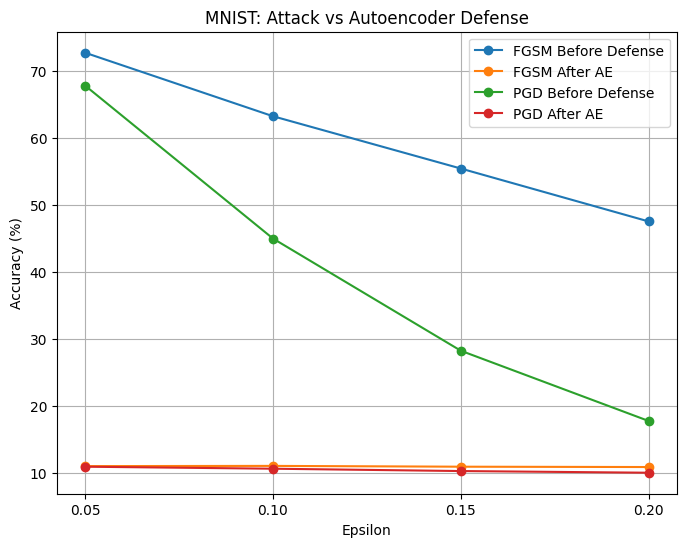

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(epsilons, mnist_fgsm_after, 'o-', label="FGSM Before Defense")
plt.plot(epsilons, mnist_fgsm_def, 'o-', label="FGSM After AE")

plt.plot(epsilons, mnist_pgd_after, 'o-', label="PGD Before Defense")
plt.plot(epsilons, mnist_pgd_def, 'o-', label="PGD After AE")

plt.xlabel("Epsilon")
plt.ylabel("Accuracy (%)")
plt.title("MNIST: Attack vs Autoencoder Defense")

plt.legend()
plt.grid()
plt.xticks(epsilons)

plt.show()

**35. Combined Visualization of FGSM & PGD Defense Across Datasets**

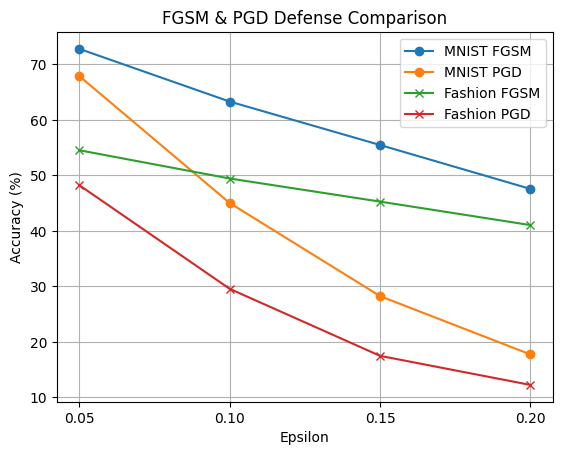

In [70]:
#combined results graph
plt.figure()

# MNIST
plt.plot(epsilons, mnist_fgsm_after, marker='o', label="MNIST FGSM")
plt.plot(epsilons, mnist_pgd_after, marker='o', label="MNIST PGD")

# Fashion-MNIST
plt.plot(epsilons, fashion_fgsm_after, marker='x', label="Fashion FGSM")
plt.plot(epsilons, fashion_pgd_after, marker='x', label="Fashion PGD")

plt.xlabel("Epsilon")
plt.ylabel("Accuracy (%)")
plt.title("FGSM & PGD Defense Comparison")

plt.legend()
plt.grid()
plt.xticks(epsilons)

plt.show()

**36. Visualize Reconstruction of Adversarial Images Using Autoencoder**

In [71]:
#Reconstruction
def show_reconstruction(model, autoencoder, loader, epsilon):
    model.eval()
    autoencoder.eval()

    images, labels = next(iter(loader))
    images = images.to(device)
    labels = labels.to(device)

    # Generate attacks
    adv_fgsm = fgsm_attack(model, images, labels, epsilon)
    adv_pgd = pgd_attack(model, images, labels, epsilon)

    # Reconstruct
    recon_fgsm = autoencoder(adv_fgsm)
    recon_pgd = autoencoder(adv_pgd)

    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 6))

    for i in range(3):
        # Row 1: Original
        plt.subplot(3, 5, i*5 + 1)
        plt.imshow(images[i].cpu().detach().squeeze(), cmap='gray')
        plt.title("Original")
        plt.axis('off')

        # Row 2: FGSM
        plt.subplot(3, 5, i*5 + 2)
        plt.imshow(adv_fgsm[i].cpu().detach().squeeze(), cmap='gray')
        plt.title("FGSM")
        plt.axis('off')

        # Row 3: PGD
        plt.subplot(3, 5, i*5 + 3)
        plt.imshow(adv_pgd[i].cpu().detach().squeeze(), cmap='gray')
        plt.title("PGD")
        plt.axis('off')

        # Row 4: Reconstructed FGSM
        plt.subplot(3, 5, i*5 + 4)
        plt.imshow(recon_fgsm[i].cpu().detach().squeeze(), cmap='gray')
        plt.title("Recon FGSM")
        plt.axis('off')

        # Row 5: Reconstructed PGD
        plt.subplot(3, 5, i*5 + 5)
        plt.imshow(recon_pgd[i].cpu().detach().squeeze(), cmap='gray')
        plt.title("Recon PGD")
        plt.axis('off')

    plt.suptitle(f"Adversarial Reconstruction (ε = {epsilon})", fontsize=14)
    plt.tight_layout()
    plt.show()

**37. Apply Reconstruction Visualization on MNIST & Fashion-MNIST**

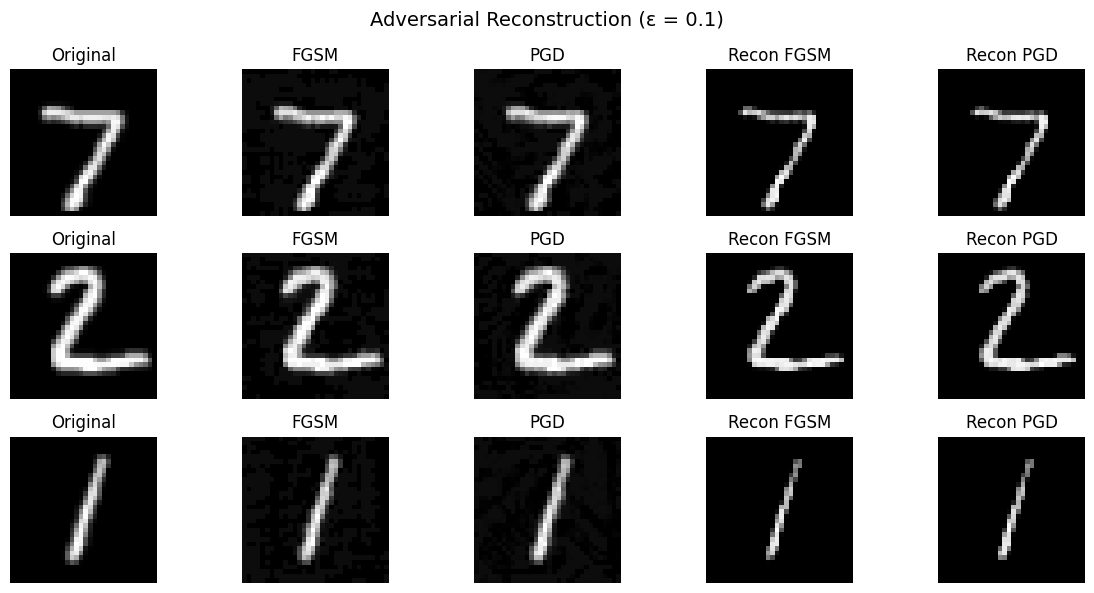

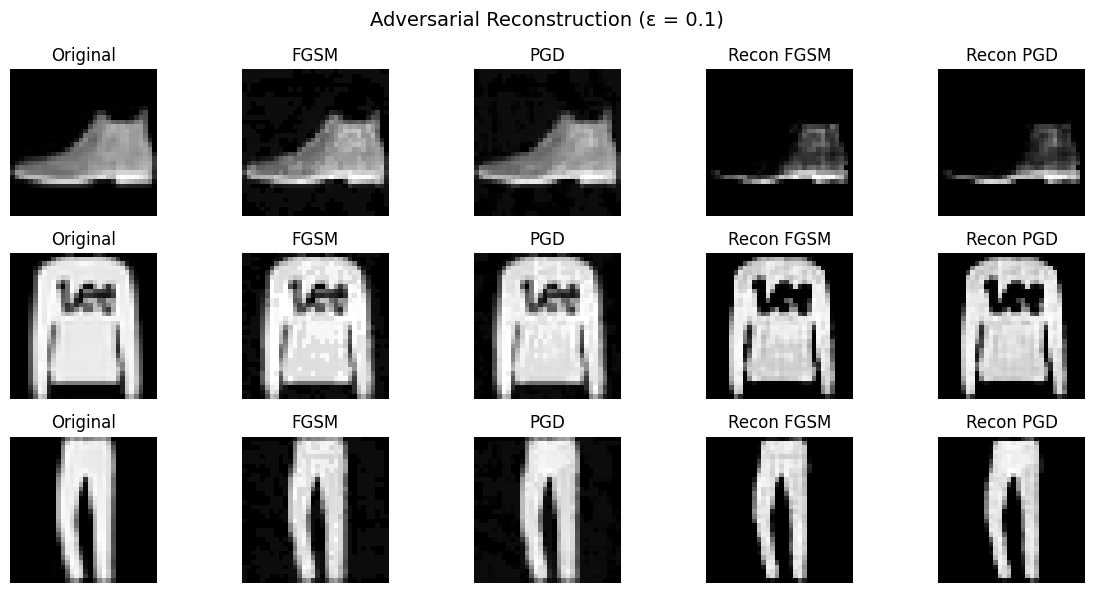

In [72]:
show_reconstruction(mnist_model, autoencoder, test_loader, epsilon=0.1)
show_reconstruction(fashion_model, autoencoder, fashion_test_loader, epsilon=0.1)

**38. Save Trained Autoencoder Model**

In [82]:
torch.save(autoencoder.state_dict(), "autoencoder.pth")